In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
from mlflow.tracking import MlflowClient

  # Change this only if needed:
MLRUNS_PATH = Path("mlruns").resolve()

EXPERIMENT_ID = "327761807019482962"

assert MLRUNS_PATH.is_dir(), f"MLflow directory not found: {MLRUNS_PATH}"

In [21]:
mlflow.set_tracking_uri(MLRUNS_PATH.as_uri())
client = MlflowClient()

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", EXPERIMENT_ID)

  # Cell 2 — load the two completed runs from that experiment

runs_all = mlflow.search_runs(
      experiment_ids=[EXPERIMENT_ID],
      output_format="pandas",
  )

if runs_all.empty:
      raise ValueError(f"No runs found in experiment {EXPERIMENT_ID}")

run_name_column = "tags.mlflow.runName"

if run_name_column not in runs_all.columns:
      raise ValueError(
          f"MLflow run-name tag is missing. Available columns:\n{runs_all.columns.tolist()}"
      )

runs_all["run_name"] = runs_all[run_name_column].fillna("")
runs_all["status"] = runs_all["status"].fillna("")

Tracking URI: file:///storage/vast-gfz-hpc-01/home/khuzaima/project/thesis_seismology/mlruns
Experiment ID: 327761807019482962


In [22]:
display(
      runs_all[
          [col for col in [
              "run_id",
              "run_name",
              "status",
              "start_time",
              "end_time",
              "metrics.val_loss",
          ] if col in runs_all.columns]
      ].sort_values("start_time")
  )

,run_id,run_name,status,start_time,end_time,metrics.val_loss
8,5d618b48ddad4a48a1c3b6c2943156dd,transfer_original,FAILED,2026-09-23 14:36:20.716000+00:00,2026-09-23 14:36:33.006000+00:00,NaN
7,d815dab9c16f482f98f8d12c03350bca,transfer_original,FINISHED,2026-09-23 14:40:52.024000+00:00,2026-09-23 14:42:00.806000+00:00,0.036195
6,7eeb691d0969430c9148c0558e573502,transfer_original,FINISHED,2026-09-23 14:53:23.399000+00:00,2026-09-23 14:54:31.531000+00:00,0.036185
5,f07c990f7039419d84e7e09aa091ebb1,transfer_original,FINISHED,2026-09-23 14:58:58.519000+00:00,2026-09-23 15:23:12.824000+00:00,0.025549
4,e0084d18af3f4f8986e31fbc8b9e7a3b,transfer_original,FINISHED,2026-09-23 15:36:43.808000+00:00,2026-09-23 17:08:20.451000+00:00,0.020702
3,e43e3e700225449ba374362dcdef7b0e,transfer_original,RUNNING,2026-09-23 18:40:27.738000+00:00,NaT,0.026488
2,8820719793bd45fca760494200caef4b,transfer_original,RUNNING,2026-09-23 18:55:31.658000+00:00,NaT,0.028400
1,84c34f0c5f484053ba790ec30492248d,transfer_original,FINISHED,2026-09-23 18:59:44.948000+00:00,2026-09-23 20:23:42.342000+00:00,0.020695
0,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,FINISHED,2026-09-23 21:55:51.384000+00:00,2026-09-23 23:04:35.655000+00:00,0.021062


In [30]:
both_model_runs = runs_all[(runs_all["run_id"]=="e0084d18af3f4f8986e31fbc8b9e7a3b") | (runs_all["run_id"]=="a13ebbf2cd1b4898877e5ac9f062bf81")]

In [31]:
selected_runs = pd.DataFrame([
      {
          "variant": "Scratch",
          "run_id": both_model_runs.iloc[0]["run_id"],
          "run_name": both_model_runs.iloc[0]["run_name"],
      },
      {
          "variant": "Transfer",
          "run_id": both_model_runs.iloc[1]["run_id"],
          "run_name": both_model_runs.iloc[1]["run_name"],
      },
  ])

In [32]:
display(selected_runs)

,variant,run_id,run_name
0,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch
1,Transfer,e0084d18af3f4f8986e31fbc8b9e7a3b,transfer_original


In [33]:
METRICS = [
      "val_loss",

      "P_f1_score", "S_f1_score",
      "global_P_f1_score", "global_S_f1_score",

      "P_precision", "S_precision",
      "global_P_precision", "global_S_precision",

      "P_recall", "S_recall",
      "global_P_recall", "global_S_recall",

      "P_mean_abs_error", "S_mean_abs_error",
      "global_P_mean_abs_error", "global_S_mean_abs_error",

      "P_rms_error", "S_rms_error",
      "global_P_rms_error", "global_S_rms_error",

      "P_auc", "S_auc",
      "global_P_auc", "global_S_auc",

      "P_optimal_threshold", "S_optimal_threshold",
      "global_P_optimal_threshold", "global_S_optimal_threshold",
  ]

In [35]:
history_rows = []

for _, run in selected_runs.iterrows():
      for metric in METRICS:
          for point in client.get_metric_history(run["run_id"], metric):
              history_rows.append(
                  {
                      "variant": run["variant"],
                      "run_id": run["run_id"],
                      "run_name": run["run_name"],
                      "metric": metric,
                      "step": point.step,
                      "timestamp": pd.to_datetime(point.timestamp, unit="ms"),
                      "value": point.value,
                  }
              )

history = pd.DataFrame(history_rows)

In [36]:
history = (
      history
      .sort_values(["run_id", "metric", "step", "timestamp"])
      .drop_duplicates(["run_id", "metric", "step"], keep="last")
  )

In [37]:
display(history.head())

,variant,run_id,run_name,metric,step,timestamp,value
2120,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,P_auc,0,2026-09-23 21:56:02.078,0.476500
2121,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,P_auc,188,2026-09-23 21:56:44.446,0.230056
2122,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,P_auc,376,2026-09-23 21:57:22.779,0.318311
2123,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,P_auc,564,2026-09-23 21:58:03.177,0.458293
2124,Scratch,a13ebbf2cd1b4898877e5ac9f062bf81,scratch,P_auc,752,2026-09-23 21:58:44.683,0.584288


In [38]:
def metric_value_at_step(run_id, metric, target_step):
      """Get the metric value at the same or nearest logged validation step."""
      values = history[
          (history["run_id"] == run_id)
          & (history["metric"] == metric)
      ].copy()

      if values.empty:
          return np.nan

      nearest_index = (values["step"] - target_step).abs().idxmin()
      return values.loc[nearest_index, "value"]


def best_validation_step(run_id):
      """The checkpoint-selection step: minimum validation loss."""
      values = history[
          (history["run_id"] == run_id)
          & (history["metric"] == "val_loss")
      ].dropna(subset=["value"])

      if values.empty:
          raise ValueError(f"No val_loss history for run {run_id}")

      return values.loc[values["value"].idxmin()]


def finite_mean(values):
      values = [value for value in values if pd.notna(value)]
      return np.mean(values) if values else np.nan

In [39]:
summary_rows = []

for _, run in selected_runs.iterrows():
      selected = best_validation_step(run["run_id"])
      step = int(selected["step"])

      row = {
          "Model": run["variant"],
          "Run name": run["run_name"],
          "Run ID": run["run_id"],
          "Best val. loss": selected["value"],
          "Selected step": step,
      }

      local_f1_values = []
      global_f1_values = []

      for phase in ["P", "S"]:
          local_f1 = metric_value_at_step(run["run_id"], f"{phase}_f1_score", step)
          global_f1 = metric_value_at_step(
              run["run_id"], f"global_{phase}_f1_score", step
          )

          local_precision = metric_value_at_step(
              run["run_id"], f"{phase}_precision", step
          )
          global_precision = metric_value_at_step(
              run["run_id"], f"global_{phase}_precision", step
          )

          local_recall = metric_value_at_step(
              run["run_id"], f"{phase}_recall", step
          )
          global_recall = metric_value_at_step(
              run["run_id"], f"global_{phase}_recall", step
          )

          local_mae = metric_value_at_step(
              run["run_id"], f"{phase}_mean_abs_error", step
          )
          global_mae = metric_value_at_step(
              run["run_id"], f"global_{phase}_mean_abs_error", step
          )

          local_rmse = metric_value_at_step(
              run["run_id"], f"{phase}_rms_error", step
          )
          global_rmse = metric_value_at_step(
              run["run_id"], f"global_{phase}_rms_error", step
          )

          local_auc = metric_value_at_step(
              run["run_id"], f"{phase}_auc", step
          )
          global_auc = metric_value_at_step(
              run["run_id"], f"global_{phase}_auc", step
          )

          row[f"{phase} local F1"] = local_f1
          row[f"{phase} global F1"] = global_f1
          row[f"{phase} F1 gain"] = local_f1 - global_f1

          row[f"{phase} local precision"] = local_precision
          row[f"{phase} global precision"] = global_precision

          row[f"{phase} local recall"] = local_recall
          row[f"{phase} global recall"] = global_recall

          row[f"{phase} local MAE (s)"] = local_mae
          row[f"{phase} global MAE (s)"] = global_mae
          row[f"{phase} MAE reduction (s)"] = global_mae - local_mae

          row[f"{phase} local RMSE (s)"] = local_rmse
          row[f"{phase} global RMSE (s)"] = global_rmse

          row[f"{phase} local AUC"] = local_auc
          row[f"{phase} global AUC"] = global_auc

          local_f1_values.append(local_f1)
          global_f1_values.append(global_f1)

      row["Local macro F1"] = finite_mean(local_f1_values)
      row["Global macro F1"] = finite_mean(global_f1_values)
      row["Macro F1 gain"] = row["Local macro F1"] - row["Global macro F1"]

      summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

display(summary.round(4))

,Model,Run name,Run ID,Best val. loss,Selected step,P local F1,P global F1,P F1 gain,P local precision,P global precision,...,S local MAE (s),S global MAE (s),S MAE reduction (s),S local RMSE (s),S global RMSE (s),S local AUC,S global AUC,Local macro F1,Global macro F1,Macro F1 gain
0,Scratch,scratch,a13ebbf2cd1b4898877e5ac9f062bf81,0.0204,17107,0.8865,0.7301,0.1564,0.8564,0.7090,...,0.0691,0.2020,0.1329,0.2328,0.4703,0.8809,0.7087,0.9042,0.7511,0.1532
1,Transfer,transfer_original,e0084d18af3f4f8986e31fbc8b9e7a3b,0.0206,18611,0.8813,0.7321,0.1493,0.8577,0.7089,...,0.0670,0.1989,0.1320,0.2251,0.4656,0.8772,0.7065,0.8994,0.7494,0.1500


In [41]:
thesis_table = summary[
      [
          "Model",
          "Best val. loss",
          "Selected step",

          "P local F1",
          "P global F1",
          "P F1 gain",
          "P local MAE (s)",
          "P global MAE (s)",
          "P MAE reduction (s)",

          "S local F1",
          "S global F1",
          "S F1 gain",
          "S local MAE (s)",
          "S global MAE (s)",
          "S MAE reduction (s)",

          "Local macro F1",
          "Global macro F1",
          "Macro F1 gain",
      ]
  ].copy()

display(thesis_table.round(4))

,Model,Best val. loss,Selected step,P local F1,P global F1,P F1 gain,P local MAE (s),P global MAE (s),P MAE reduction (s),S local F1,S global F1,S F1 gain,S local MAE (s),S global MAE (s),S MAE reduction (s),Local macro F1,Global macro F1,Macro F1 gain
0,Scratch,0.0204,17107,0.8865,0.7301,0.1564,0.0640,0.4263,0.3623,0.9220,0.7720,0.1499,0.0691,0.2020,0.1329,0.9042,0.7511,0.1532
1,Transfer,0.0206,18611,0.8813,0.7321,0.1493,0.0747,0.4277,0.3529,0.9174,0.7667,0.1507,0.0670,0.1989,0.1320,0.8994,0.7494,0.1500


In [42]:
COLORS = {
      "Scratch": "tab:blue",
      "Transfer": "tab:orange",
  }

def plot_local_vs_global(metric_suffix, ylabel, ylim=None):
      fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)

      for phase, ax in zip(["P", "S"], axes):
          for _, run in selected_runs.iterrows():
              variant = run["variant"]
              run_id = run["run_id"]
              color = COLORS[variant]

              local = history[
                  (history["run_id"] == run_id)
                  & (history["metric"] == f"{phase}_{metric_suffix}")
              ]

              global_model = history[
                  (history["run_id"] == run_id)
                  & (history["metric"] == f"global_{phase}_{metric_suffix}")
              ]

              ax.plot(
                  local["step"],
                  local["value"],
                  color=color,
                  linewidth=2,
                  label=f"{variant} model",
              )

              ax.plot(
                  global_model["step"],
                  global_model["value"],
                  color=color,
                  linewidth=2,
                  linestyle="--",
                  alpha=0.85,
                  label=f"Global during {variant.lower()} run",
              )

          ax.set_title(f"{phase}-phase")
          ax.set_xlabel("MLflow validation step")
          ax.grid(alpha=0.3)

          if ylim is not None:
              ax.set_ylim(*ylim)

      axes[0].set_ylabel(ylabel)
      axes[1].legend(fontsize=8)
      fig.suptitle("Validation diagnostics: local models versus global/original PhaseNet")
      plt.tight_layout()
      plt.show()

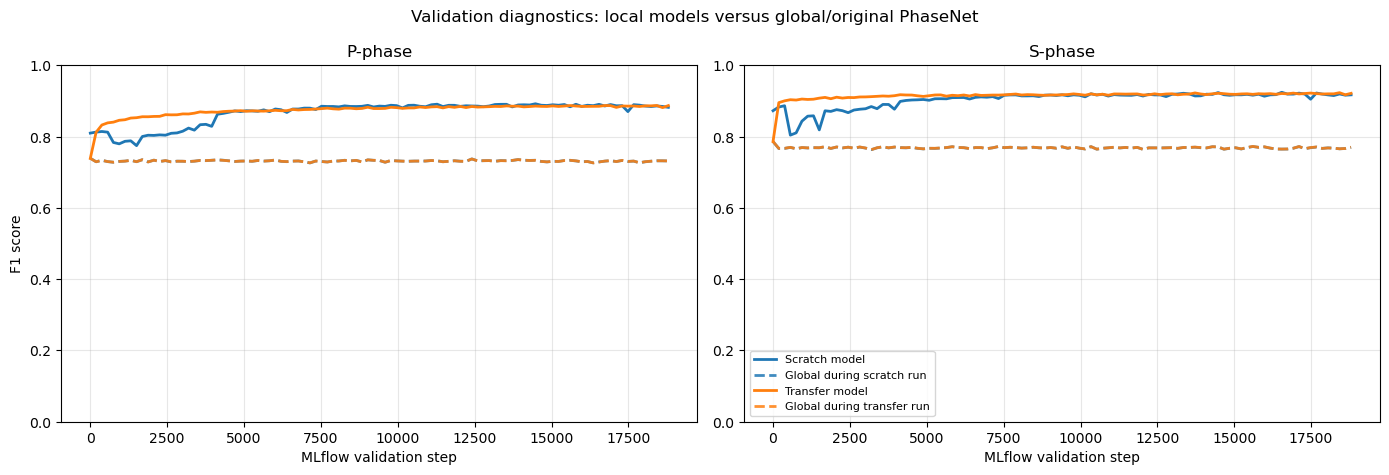

In [43]:
plot_local_vs_global(
      metric_suffix="f1_score",
      ylabel="F1 score",
      ylim=(0, 1),
  )

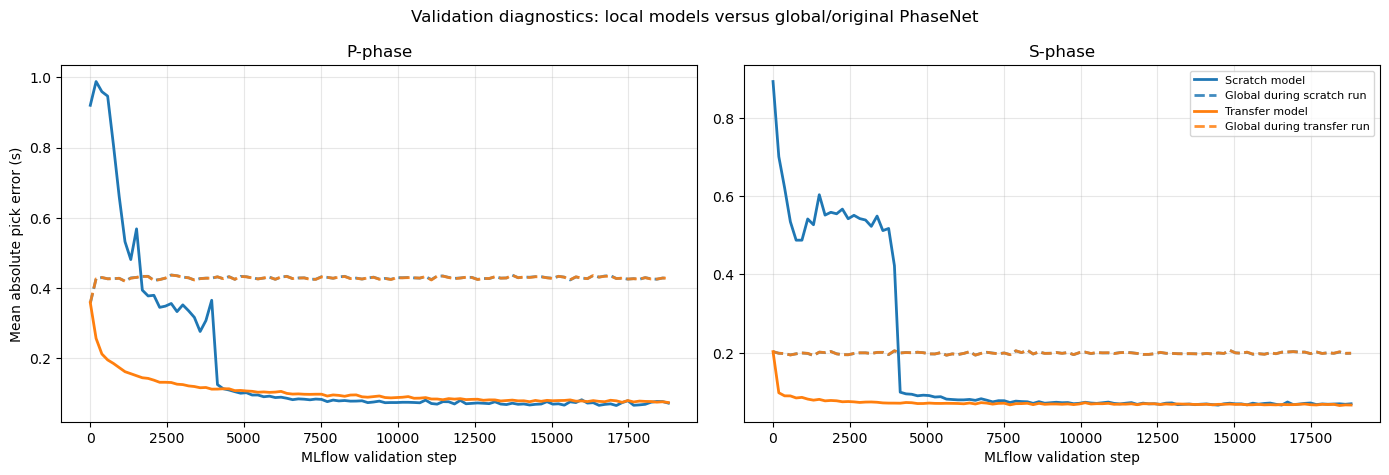

In [44]:
plot_local_vs_global(
      metric_suffix="mean_abs_error",
      ylabel="Mean absolute pick error (s)",
  )

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

for _, run in selected_runs.iterrows():
      values = history[
          (history["run_id"] == run["run_id"])
          & (history["metric"] == "val_loss")
      ]

      ax.plot(
          values["step"],
          values["value"],
          linewidth=2,
          color=COLORS[run["variant"]],
          label=f"{run['variant']} model",
      )

ax.set_xlabel("MLflow validation step")
ax.set_ylabel("Validation loss")
ax.set_title("Scratch versus transfer-learning convergence")
ax.grid(alpha=0.3)
ax.legend()
  plt.tight_layout()
  plt.show()

IndentationError: unindent does not match any outer indentation level (<string>, line 17)